In [ ]:
# -*- coding: utf-8 -*-
"""
Example script to serve as starting point for display the results of the brain simulation

The current script reads results from the simulation and displays them.

Prerequisite:
You should have executed the following on your command prompt
    ./run_simulation_brain.sh

Author: Kris Thielemans
"""

In [ ]:
%matplotlib notebook

# Initial imports

In [1]:
import os
import sys

# Ensure STIR Python modules are importable even when PYTHONPATH is not set
STIR_SWIG_BUILD = '/home/z004x71x/GitHubLocal/STIR/STIR/build-debug/src/swig'
STIR_SWIG_SRC = '/home/z004x71x/GitHubLocal/STIR/STIR/src/swig'
for _p in (STIR_SWIG_BUILD, STIR_SWIG_SRC):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy
import matplotlib.pyplot as plt
import stir
from stirextra import *

# go to directory with input files

In [2]:
# adapt this path to your situation (or start everything in the exercises directory)
base_dir = os.getenv('STIR_exercises_PATH') or '/home/z004x71x/GitHubLocal/STIR/STIR-exercises'
os.chdir(base_dir)
print('Using base dir:', os.getcwd())

Using base dir: /home/z004x71x/GitHubLocal/STIR/STIR-exercises


# change directory to where the output files are

In [3]:
os.chdir('working_folder/brain')

# Read in images

In [4]:
image=to_numpy(stir.FloatVoxelsOnCartesianGrid.read_from_file('emission.hv'));
mu_map=to_numpy(stir.FloatVoxelsOnCartesianGrid.read_from_file('attenuation.hv'));

# bitmap display of images

/home/z004x71x/GitHubLocal/STIR/STIR-exercises/venv-stir-exercises/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/z004x71x/GitHubLocal/STIR/STIR-exercises/venv-stir-exercises/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


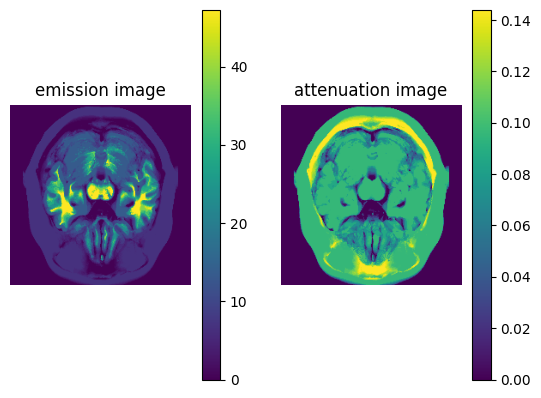

In [5]:
slice=7;
fig=plt.figure();
ax=plt.subplot(1,2,1);
plt.imshow(image[slice,:,:,]);
plt.colorbar();
plt.axis('off');
ax.set_title('emission image');

ax=plt.subplot(1,2,2);
plt.imshow(mu_map[slice,:,:,]);
plt.colorbar();
plt.axis('off');
ax.set_title('attenuation image');

fig.savefig('input_images.png')

# read in sinograms

In [6]:
# prompts (i.e. all counts) including trues and randoms)
prompts=to_numpy(stir.ProjData.read_from_file('my_prompts.hs'));
# scatter (zero for the brain simulation)
scatter=to_numpy(stir.ProjData.read_from_file('my_scatter.hs'));
# randoms (constant)
randoms=to_numpy(stir.ProjData.read_from_file('my_randoms.hs'));

# Some STIR versions return an extra leading singleton dimension (e.g. (1, S, V, T)).
# Squeeze it so downstream indexing with prompts[sinogram, view, tangential] remains valid.
if prompts.ndim == 4 and prompts.shape[0] == 1:
    prompts = prompts[0]
if scatter.ndim == 4 and scatter.shape[0] == 1:
    scatter = scatter[0]
if randoms.ndim == 4 and randoms.shape[0] == 1:
    randoms = randoms[0]

print('prompts shape after normalization:', prompts.shape)
print('scatter shape after normalization:', scatter.shape)
print('randoms shape after normalization:', randoms.shape)


INFO: Detected view-mashing factor 4 from the number of views (64) and the number of detectors per ring (512).
Adjusting the azimuthal angle offset accordingly (an extra offset of 1.05469 degrees)

INFO: Detected view-mashing factor 4 from the number of views (64) and the number of detectors per ring (512).
Adjusting the azimuthal angle offset accordingly (an extra offset of 1.05469 degrees)
prompts shape after normalization: (15, 64, 90)
scatter shape after normalization: (15, 64, 90)
randoms shape after normalization: (15, 64, 90)












Scanner parameters:=
  Scanner type := userdefined
  Number of rings                          := 8
  Number of detectors per ring             := 512
  Inner ring diameter (cm)                 := 102
  Average depth of interaction (cm)        := 0.7
  Distance between rings (cm)              := 1.35
  Default bin size (cm)                    := 0.3129
  View offset (degrees)                    := 0
  Maximum number of non-arc-corrected bins := 192
  Default number of arc-corrected bins     := 192
  Number of blocks per bucket in transaxial direction         := 1
  Number of blocks per bucket in axial direction              := 1
  Number of crystals per block in axial direction             := 1
  Number of crystals per block in transaxial direction        := 8
  Number of detector layers                                   := 1
  Number of crystals per singles unit in axial direction      := 1
  Number of crystals per singles unit in transaxial direction := 8
  Scanner geometry (

# A note on projection data sizes

In [7]:
# In STIR Python, projection data after conversion to numpy is currently always a 3D array. This
# simulation is of an acquisition in "2D" mode, but with several rings of detectors.
# In that case, the projection  data has size num_sinograms x num_views x num_tangential_positions.
# In "3D" acquisition mode, the situation is more complicated. Effectively all "segments"
# are concatenated. You can ignore this terminology now, or check it out at
# http://stir.sourceforge.net/documentation/STIR-glossary.pdf
prompts.shape

(1, 15, 64, 90)

# Display bitmaps of a middle sinogram

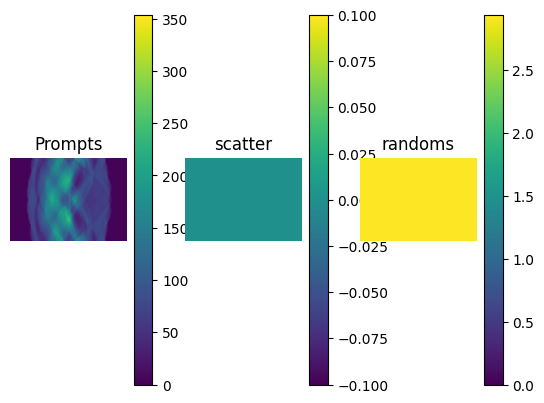

In [7]:
# Note that scatter is zero in this brain simulation
fig=plt.figure()
ax=plt.subplot(1,3,1);
plt.imshow(prompts[5,:,:,]);
plt.clim(0,prompts.max())
ax.set_title('Prompts');
plt.axis('off');
plt.colorbar()

ax=plt.subplot(1,3,2);
plt.imshow(scatter[5,:,:,]);
plt.clim(0,scatter.max());
ax.set_title('scatter');
plt.axis('off');
plt.colorbar()

ax=plt.subplot(1,3,3);
plt.imshow(randoms[5,:,:,]);
plt.clim(0,randoms.max());
ax.set_title('randoms');
plt.axis('off');
plt.colorbar()

fig.savefig('sinogram_bitmaps.png')

# Display central horizontal profiles through the sinogram

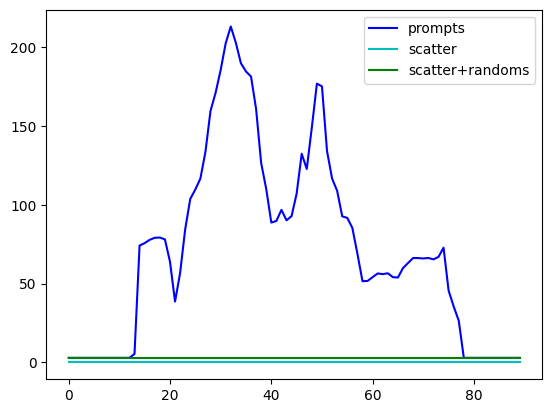

In [8]:
fig=plt.figure()
#plt.hold(True)
plt.plot(prompts[5,64//2,:],'b');
plt.plot(scatter[5,64//2,:],'c');
plt.plot((scatter+randoms)[5,64//2,:],'g');
plt.legend(('prompts','scatter', 'scatter+randoms'));

fig.savefig('sinogram_profiles.png')

# Display some different views in an a movie

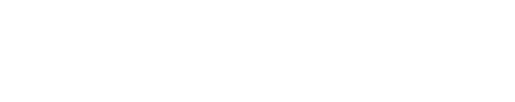

In [11]:
import matplotlib.animation as animation
bitmaps=[]
fig=plt.figure()
for view in range(0,64,4):
    bitmap=plt.imshow(prompts[:,view,:,]);
    plt.clim(0,prompts.max())
    #plt.set_title('Prompts view %d');
    plt.axis('off');
    bitmaps.append([bitmap])

ani = animation.ArtistAnimation(fig, bitmaps, interval=100, blit=True, repeat_delay=1000)

# close all plots

In [10]:
plt.close('all')